<a href="https://colab.research.google.com/github/EduardoZamora03/Proyecto-samsung/blob/main/Clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Clases a sobremuestrear:
{'Wipro_bulb': 300, 'NMAP_UDP_SCAN': 300, 'NMAP_XMAS_TREE_SCAN': 300, 'NMAP_OS_DETECTION': 300, 'DOS_SYN_Hping': 300, 'NMAP_TCP_scan': 300, 'Metasploit_Brute_Force_SSH': 300}

Entrenando modelo...
Listo.

Accuracy: 0.9850

                            precision    recall  f1-score   support

            ARP_poisioning       0.97      0.99      0.98      1060
            DDOS_Slowloris       0.94      0.88      0.91       107
             DOS_SYN_Hping       1.00      1.00      1.00        11
              MQTT_Publish       1.00      1.00      1.00       828
Metasploit_Brute_Force_SSH       1.00      0.57      0.73         7
         NMAP_OS_DETECTION       0.94      1.00      0.97        15
             NMAP_TCP_scan       1.00      1.00      1.00         9
             NMAP_UDP_SCAN       0.67      0.72      0.69        39
       NMAP_XMAS_TREE_SCAN       1.00      0.94      0.97        16
               Thing_Speak       1.00      0.99      0.99      1520
   

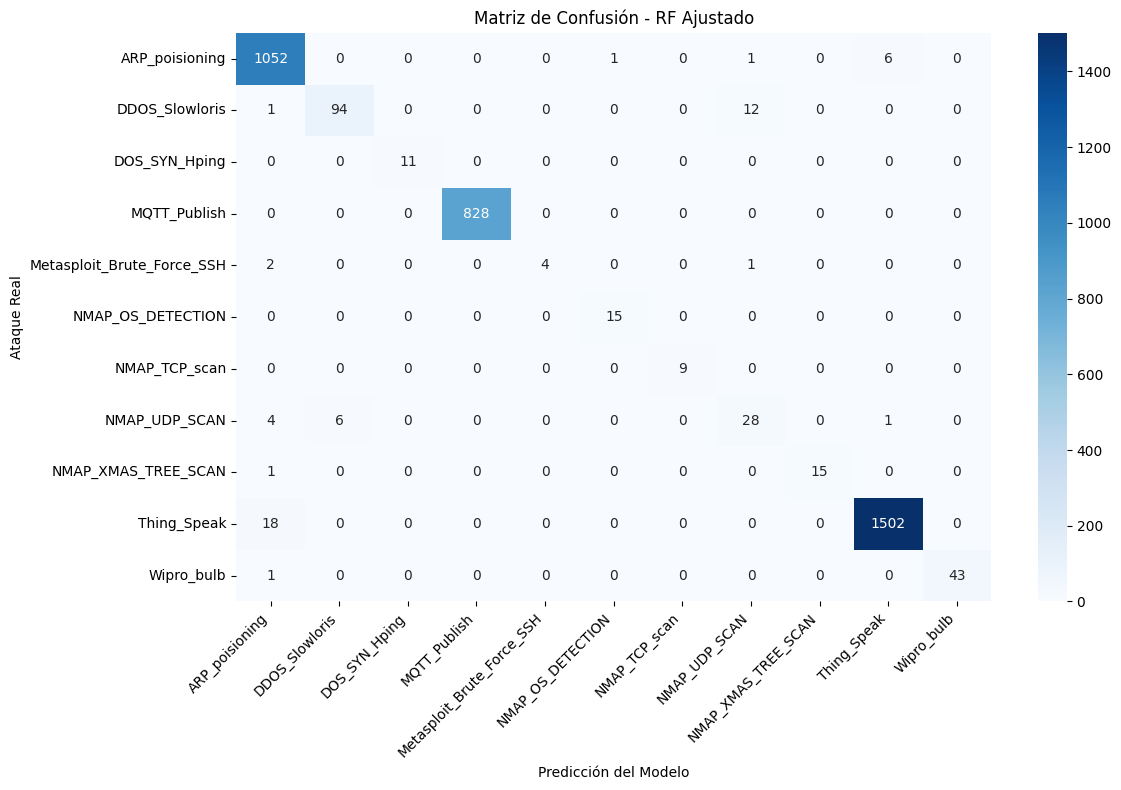

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt

print(" CLASIFICACION ")

# Carga de datos
df_class = pd.read_csv('RT_IOT2022_clasificacion_limpio.csv')

X = df_class.drop('Attack_type', axis=1)
y = df_class['Attack_type']

# Division de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE
conteos_train = y_train.value_counts()
UMBRAL_SMOTE = 300
sampling_strategy = {
    clase: UMBRAL_SMOTE
    for clase, n in conteos_train.items()
    if n < UMBRAL_SMOTE
}
print("Clases a sobremuestrear:")
print(sampling_strategy)

# Pipeline con parámetros ajustados manualmente
# Estos valores son los que más impacto tienen en clases minoritarias
pipeline_rf = Pipeline([
    ('smote', SMOTE(
        sampling_strategy=sampling_strategy,
        k_neighbors=3,
        random_state=42
    )),
    ('clf', RandomForestClassifier(
        n_estimators=200,      # más árboles = más estabilidad en clases pequeñas
        max_depth=30,          # evita sobreajuste en clases con pocos datos
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])

# Entrenar
print("\nEntrenando modelo...")
pipeline_rf.fit(X_train, y_train)
print("Listo.")

# Evaluar
predicciones = pipeline_rf.predict(X_test)
accuracy = pipeline_rf.score(X_test, y_test)

print(f"\nAccuracy: {accuracy:.4f}\n")
print(classification_report(y_test, predicciones))

# Matriz de confusión
labels = sorted(y.unique())
cm = confusion_matrix(y_test, predicciones, labels=labels)

plt.figure(figsize=(12, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.title('Matriz de Confusión - RF Ajustado')
plt.ylabel('Ataque Real')
plt.xlabel('Predicción del Modelo')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()